In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# DATA CLEANING AND EXPLORATORY DATA ANALYSIS
# ============================================================


# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

path = r"C:\Users\pn125\Downloads\Titanic.csv"

df = pd.read_csv(path)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())


Dataset Shape: (1309, 14)

First 5 Rows:


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [23]:
# ------------------------------------------------------------
# 2. UNDERSTAND THE DATA
# ------------------------------------------------------------

print("\nDataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

print("\nStatistical Summary:")
display(df.describe(include="all"))


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1309 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   str    
 8   fare       1309 non-null   float64
 9   cabin      1309 non-null   str    
 10  embarked   1309 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 143.3 KB

Column Names:
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

Statistical Summary:


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
count,1309.000000,1309.000000,1309,1309,1309.000000,1309.000000,1309.000000,1309,1309.000000,1309,1309,486,121.000000,745
unique,NaN,NaN,1307,2,NaN,NaN,NaN,929,NaN,187,3,27,NaN,369
top,NaN,NaN,"Connolly, Miss. Kate",male,NaN,NaN,NaN,CA. 2343,NaN,Unknown,S,13,NaN,"New York, NY"
freq,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,1014,916,39,NaN,64
mean,2.294882,0.381971,NaN,NaN,29.503186,0.498854,0.385027,NaN,33.281086,NaN,NaN,NaN,160.809917,NaN
std,0.837836,0.486055,NaN,NaN,12.905241,1.041658,0.865560,NaN,51.741500,NaN,NaN,NaN,97.696922,NaN
min,1.000000,0.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN
25%,2.000000,0.000000,NaN,NaN,22.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,NaN,72.000000,NaN
50%,3.000000,0.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,155.000000,NaN
75%,3.000000,1.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN,NaN,256.000000,NaN


In [22]:
# ------------------------------------------------------------
# 3. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Values Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing Values:
pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            0
cabin           0
embarked        0
boat          823
body         1188
home.dest     564
dtype: int64

Missing Values Percentage:
pclass        0.00
survived      0.00
name          0.00
sex           0.00
age           0.00
sibsp         0.00
parch         0.00
ticket        0.00
fare          0.00
cabin         0.00
embarked      0.00
boat         62.87
body         90.76
home.dest    43.09
dtype: float64


In [21]:
# ============================================================
# DATA CLEANING
# ============================================================
# ------------------------------------------------------------
# 4. CHECK DUPLICATE ROWS
# ------------------------------------------------------------

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


Number of Duplicate Rows:
0


In [20]:
# ------------------------------------------------------------
# 5. HANDLE MISSING VALUES
# ------------------------------------------------------------

# Fill missing age with median
df["age"] = df["age"].fillna(df["age"].median())

# Fill missing embarked with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Fill missing fare with median
df["fare"] = df["fare"].fillna(df["fare"].median())

# Fill missing cabin with "Unknown"
df["cabin"] = df["cabin"].fillna("Unknown")

In [19]:
# ------------------------------------------------------------
# 6. REMOVE DUPLICATES
# ------------------------------------------------------------

df = df.drop_duplicates()

In [17]:
# ------------------------------------------------------------
# 7. CHECK DATA AFTER CLEANING
# ------------------------------------------------------------

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:")
print(df.shape)





Missing Values After Cleaning:
pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            0
cabin           0
embarked        0
boat          823
body         1188
home.dest     564
dtype: int64

Dataset Shape After Cleaning:
(1309, 14)


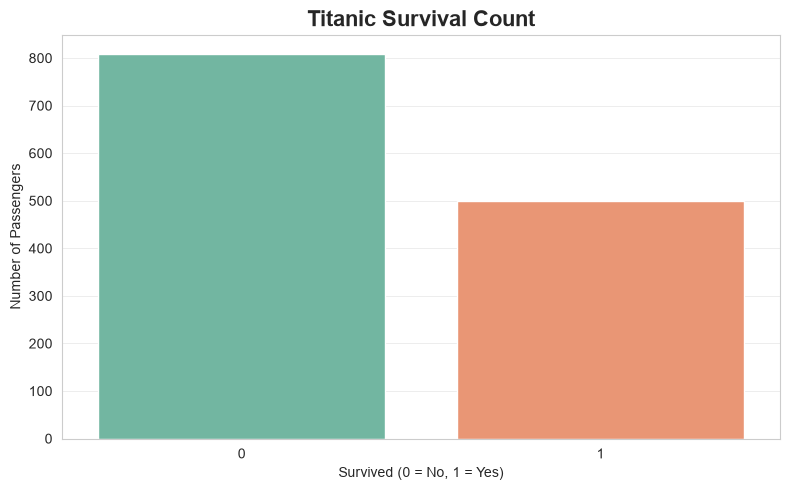

In [18]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================

sns.set_style("whitegrid")
# ------------------------------------------------------------
# 8. SURVIVAL COUNT
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="survived",
    hue="survived",
    palette="Set2",
    legend=False
)

plt.title(
    "Titanic Survival Count",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

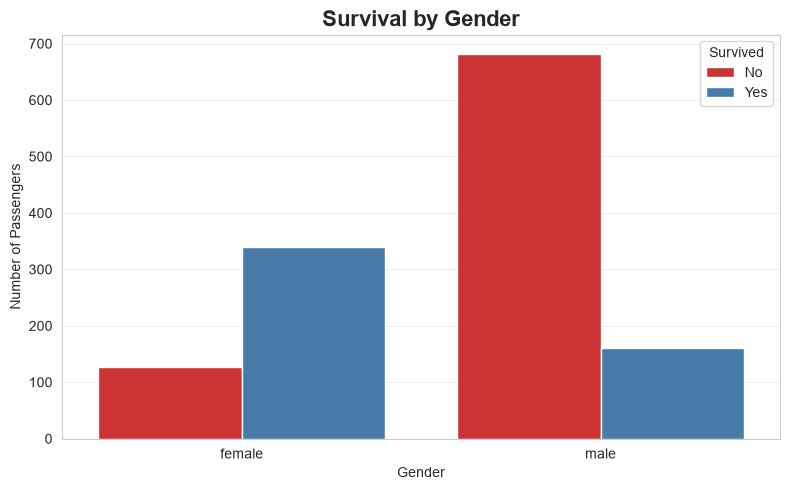

In [15]:
# ------------------------------------------------------------
# 9. SURVIVAL BY GENDER
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sex",
    hue="survived",
    palette="Set1"
)

plt.title(
    "Survival by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.tight_layout()
plt.show()


Survival Rate by Gender:
sex
female    72.75
male      19.10
Name: survived, dtype: float64


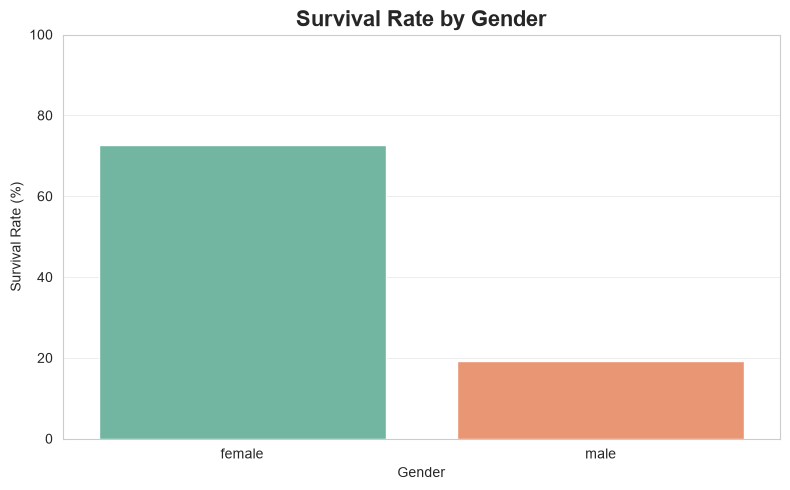

In [14]:
# ------------------------------------------------------------
# 10. SURVIVAL RATE BY GENDER
# ------------------------------------------------------------

survival_gender = df.groupby("sex")["survived"].mean() * 100

print("\nSurvival Rate by Gender:")
print(survival_gender.round(2))


plt.figure(figsize=(8, 5))

sns.barplot(
    x=survival_gender.index,
    y=survival_gender.values,
    hue=survival_gender.index,
    palette="Set2",
    legend=False
)

plt.title(
    "Survival Rate by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

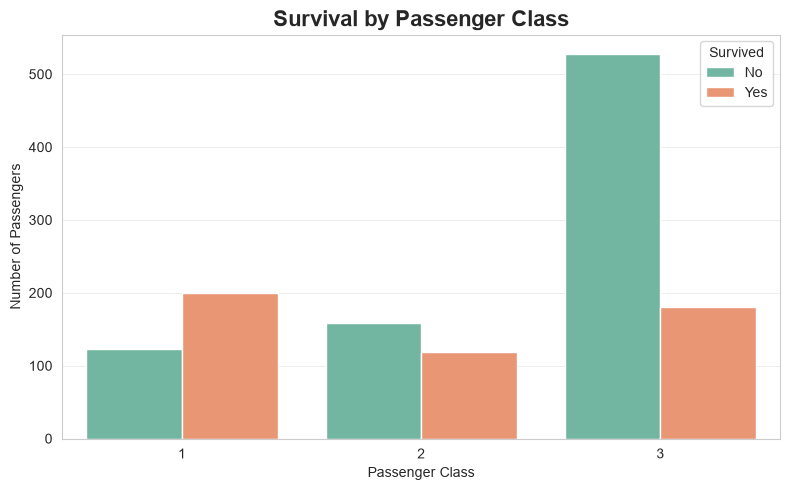

In [13]:
# ------------------------------------------------------------
# 11. SURVIVAL BY PASSENGER CLASS
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="pclass",
    hue="survived",
    palette="Set2"
)

plt.title(
    "Survival by Passenger Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.tight_layout()
plt.show()


Survival Rate by Passenger Class:
pclass
1    61.92
2    42.96
3    25.53
Name: survived, dtype: float64


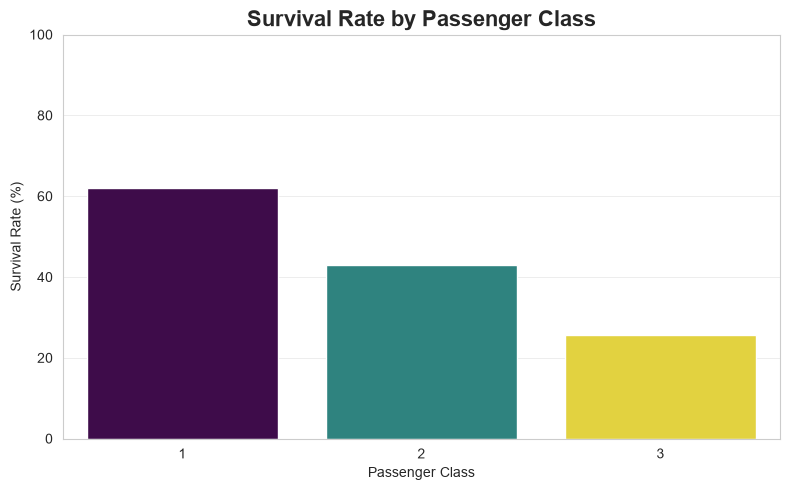

In [12]:
# ------------------------------------------------------------
# 12. SURVIVAL RATE BY PASSENGER CLASS
# ------------------------------------------------------------

survival_class = df.groupby("pclass")["survived"].mean() * 100

print("\nSurvival Rate by Passenger Class:")
print(survival_class.round(2))


plt.figure(figsize=(8, 5))

sns.barplot(
    x=survival_class.index,
    y=survival_class.values,
    hue=survival_class.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Survival Rate by Passenger Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

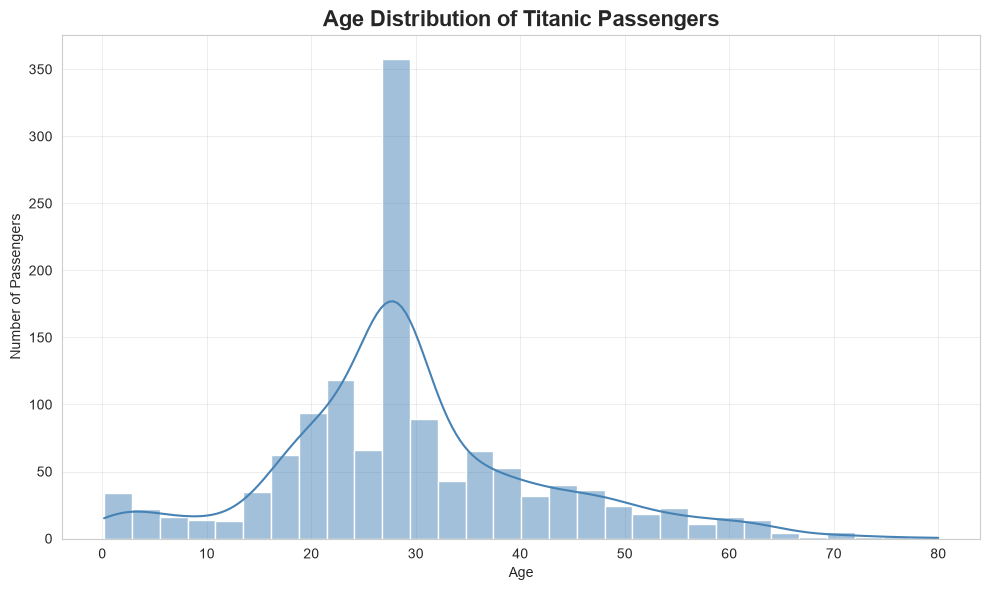

In [11]:
# ------------------------------------------------------------
# 13. AGE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title(
    "Age Distribution of Titanic Passengers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

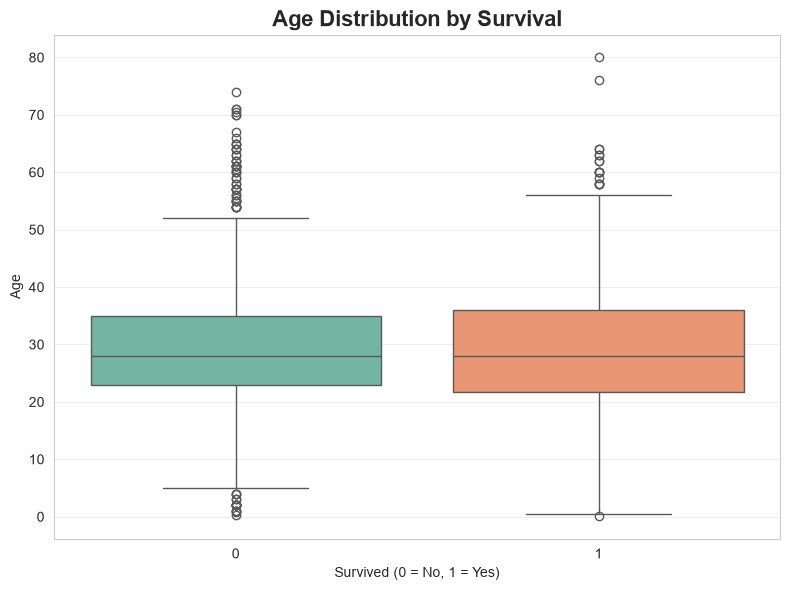

In [10]:
# ------------------------------------------------------------
# 14. AGE VS SURVIVAL
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="survived",
    y="age",
    hue="survived",
    palette="Set2",
    legend=False
)

plt.title(
    "Age Distribution by Survival",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

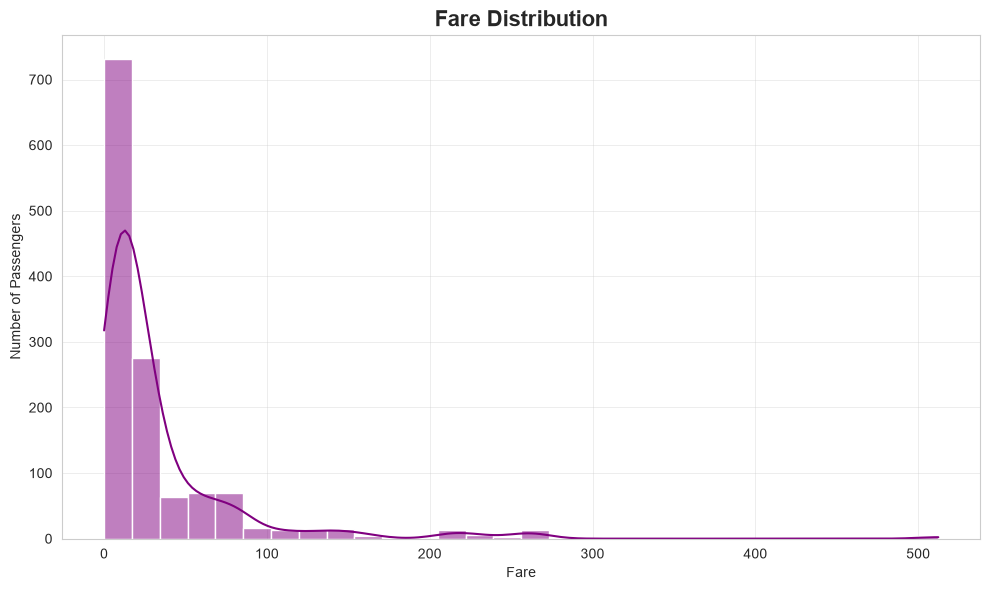

In [9]:
# ------------------------------------------------------------
# 15. FARE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="fare",
    bins=30,
    kde=True,
    color="purple"
)

plt.title(
    "Fare Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

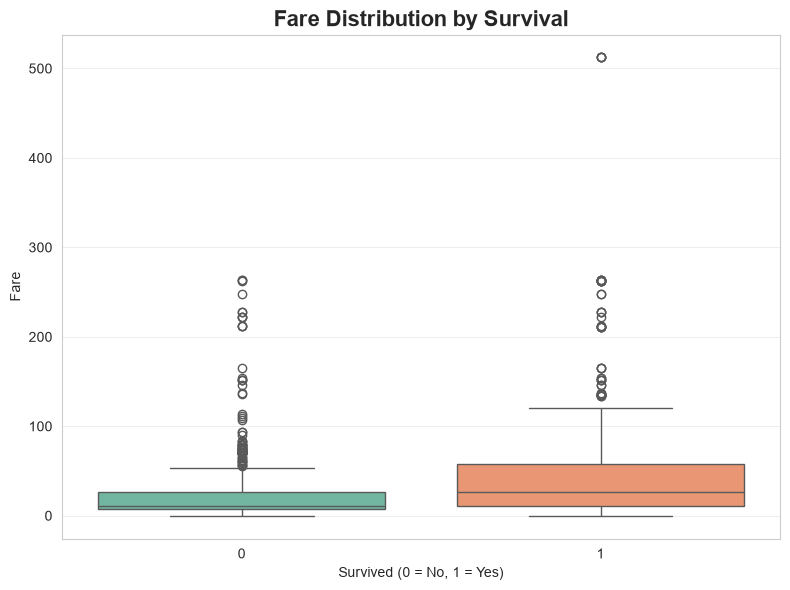

In [8]:
# ------------------------------------------------------------
# 16. FARE VS SURVIVAL
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="survived",
    y="fare",
    hue="survived",
    palette="Set2",
    legend=False
)

plt.title(
    "Fare Distribution by Survival",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 17. EMBARKED VS SURVIVAL
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="embarked",
    hue="survived",
    palette="Set1"
)

plt.title(
    "Survival by Embarkation Port",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Port of Embarkation")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.tight_layout()
plt.show()

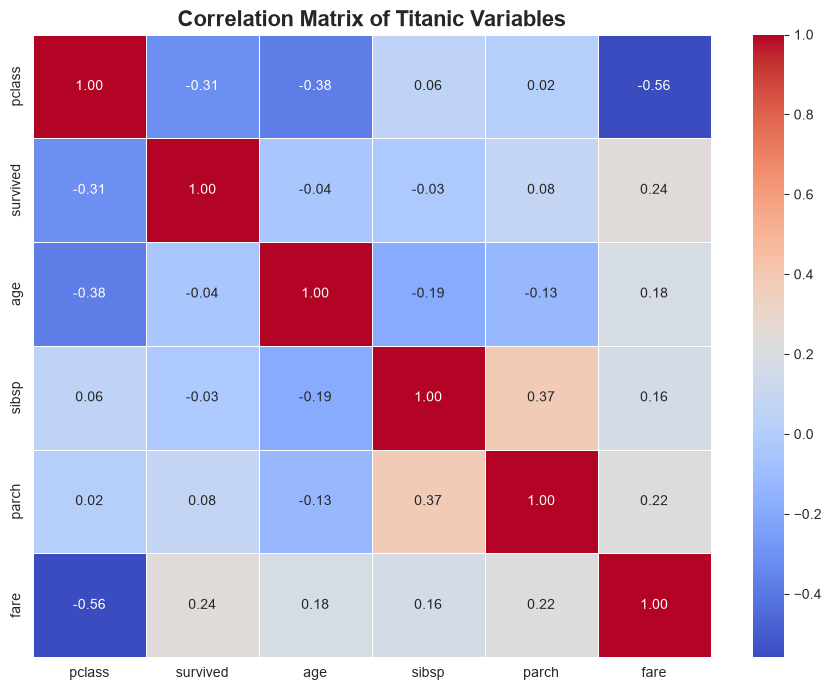

In [7]:
# ------------------------------------------------------------
# 18. CORRELATION HEATMAP
# ------------------------------------------------------------

numeric_columns = [
    "pclass",
    "survived",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Titanic Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


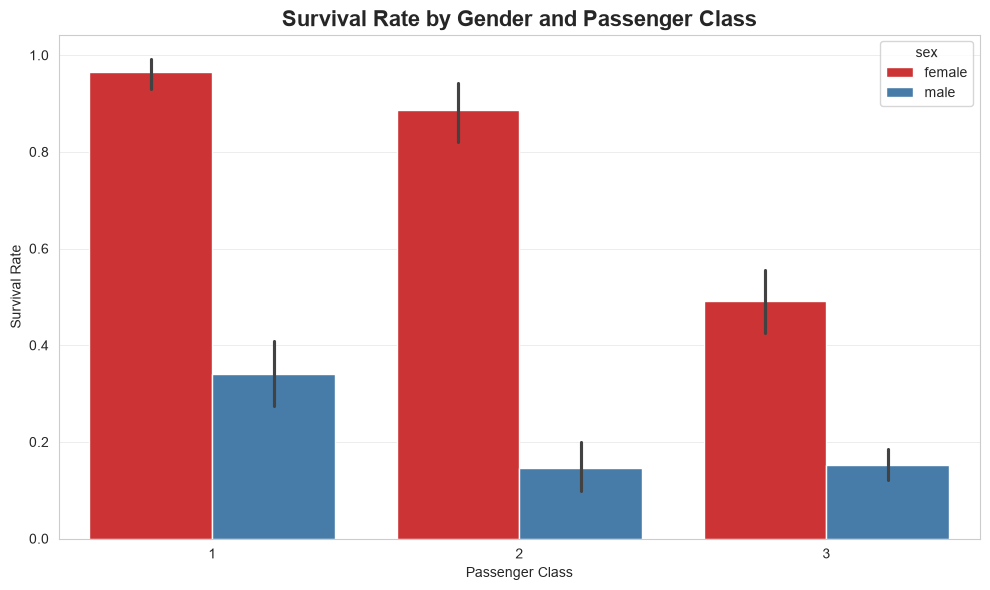

In [6]:
# ------------------------------------------------------------
# 19. SURVIVAL BY GENDER AND CLASS
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex",
    palette="Set1"
)

plt.title(
    "Survival Rate by Gender and Passenger Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.show()



In [5]:
# ------------------------------------------------------------
# 20. KEY FINDINGS
# ------------------------------------------------------------

print("\n============================================================")
print("KEY FINDINGS")
print("============================================================")

print("\nOverall Survival Rate:")
print(round(df["survived"].mean() * 100, 2), "%")

print("\nSurvival Rate by Gender:")
print((df.groupby("sex")["survived"].mean() * 100).round(2))

print("\nSurvival Rate by Passenger Class:")
print((df.groupby("pclass")["survived"].mean() * 100).round(2))

print("\nAverage Age of Passengers:")
print(round(df["age"].mean(), 2))

print("\nAverage Fare:")
print(round(df["fare"].mean(), 2))

print("\nTask-02 EDA Completed Successfully!")


KEY FINDINGS

Overall Survival Rate:
38.2 %

Survival Rate by Gender:
sex
female    72.75
male      19.10
Name: survived, dtype: float64

Survival Rate by Passenger Class:
pclass
1    61.92
2    42.96
3    25.53
Name: survived, dtype: float64

Average Age of Passengers:
29.5

Average Fare:
33.28

Task-02 EDA Completed Successfully!
